# Pacman Deep Q-Network (DQN) with Stable-Baselines3

This notebook demonstrates training a **Deep Q-Network (DQN)** agent on the **Pacman Classic** environment using **Stable-Baselines3** and PyTorch GPU acceleration.

### Architecture Highlights
- **Observation Space**: Nature Atari CNN (`CnnPolicy`) with **84x84 Grayscale** images.
- **Temporal Stacking**: **4 consecutive frames** stacked (`(4, 84, 84)`) to infer entity velocity and trajectory directions.
- **Action Repeat (Frame Skipping)**: **4 simulation ticks per action**, matching standard Atari benchmarks for fast exploration and learning.
- **Reward Shaping**: Custom event-driven rewards rewarding pellet consumption, power pellet activation, ghost hunting, and survival.
- **Inference & Video Replay**: High-resolution RGB video recording embedded directly into the notebook.


## 1. Imports and GPU Verification


In [1]:
import os
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from IPython.display import Image, display
from PIL import Image as PILImage
from stable_baselines3 import DQN

from pacman_engine import PacmanEnv

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Target computation device: {device}")

PyTorch version: 2.13.0+cu130
CUDA available: True
GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU
Target computation device: cuda


## 2. Event-Driven Reward Shaping

In Reinforcement Learning, the raw arcade score alone can be sparse. We design a specialized reward function using typed `GameEvent` objects emitted by `PacmanEnv`:

- **Standard Pellet (`PelletEaten`)**: `+1.0`
- **Energizer Power Pellet (`PowerPelletEaten`)**: `+5.0`
- **Ghost Hunted (`GhostEaten`)**: `+20.0`
- **Lethal Collision (`PacmanDied`)**: `-20.0`
- **Level Cleared (`LevelCleared` / `Win`)**: `+50.0`
- **Time-step Penalty**: `-0.01` per tick (promotes efficient maze clearing)


In [2]:
def pacman_reward_shaping(step_result, view) -> float:
    """Custom reward shaping function based on simulation events and state."""
    reward = -0.01  # Small step penalty to discourage stalling

    for event in step_result.events:
        name = type(event).__name__
        if name == "PelletEaten":
            reward += 1.0
        elif name == "PowerPelletEaten":
            reward += 5.0
        elif name == "GhostEaten":
            reward += 20.0
        elif name == "PacmanDied":
            reward -= 20.0
        elif name in ("LevelCleared", "Win"):
            reward += 50.0

    return reward

## 3. Environment Instantiation & Frame Inspection

We configure `PacmanEnv` with:
- `map_name="classic"`: The authentic 28x31 arcade maze with 4 ghosts.
- `obs_type="rgb"`: Grayscale 84x84, channels-first `(1, 84, 84)`.
- `frame_skip=4`: Repeats action for 4 simulation ticks.
- `frame_stack=4`: Stacks 4 frames into a `(4, 84, 84)` tensor.
- `lives=1`: Single-life training episode for clean RL termination.


Observation Space: Box(0, 255, (4, 84, 84), uint8)
Action Space:      Discrete(5) (0: UP, 1: DOWN, 2: LEFT, 3: RIGHT, 4: STAY)
Stacked observation shape: (4, 84, 84)


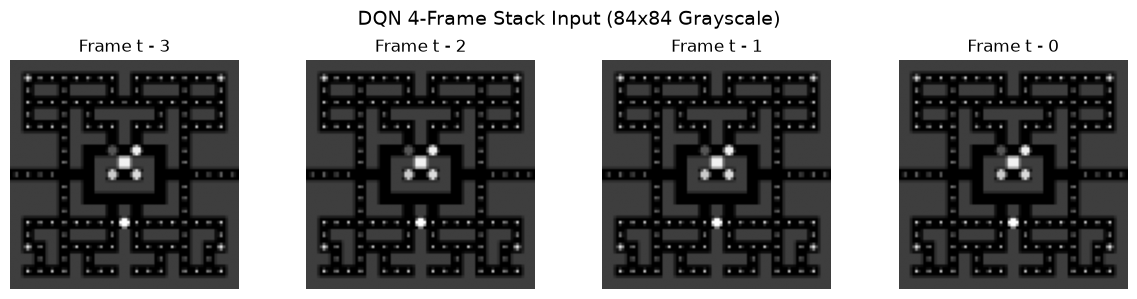

In [3]:
# Create the training environment
train_env = PacmanEnv(
    map_name="classic",
    obs_type="rgb",
    obs_params={
        "grayscale": True,
        "channels_first": True,
        "output_size": (84, 84),
    },
    reward_func=pacman_reward_shaping,
    frame_skip=4,
    frame_stack=4,
    lives=1,
    max_steps=1000,
    render_mode="rgb_array",
)

print(f"Observation Space: {train_env.observation_space}")
print(f"Action Space:      {train_env.action_space} (0: UP, 1: DOWN, 2: LEFT, 3: RIGHT, 4: STAY)")

# Reset environment and visualize stacked frames
obs, info = train_env.reset(seed=42)
print(f"Stacked observation shape: {obs.shape}")

# Visualize the 4 stacked grayscale channels
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(obs[i], cmap="gray")
    axes[i].set_title(f"Frame t - {3 - i}")
    axes[i].axis("off")
plt.suptitle("DQN 4-Frame Stack Input (84x84 Grayscale)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. DQN Agent Configuration

We initialize the DQN agent with standard Nature Atari hyperparameters:
- **Feature Extractor**: 3-layer Convolutional Neural Network (Atari Nature CNN).
- **Replay Buffer**: Memory buffer storing transition tuples `(s, a, r, s', done)`.
- **Exploration Schedule**: Epsilon-greedy decaying from 1.0 to 0.05.


In [4]:
# Directories for model checkpoints and tensorboard logs
os.makedirs("models", exist_ok=True)
os.makedirs("tensorboard_logs", exist_ok=True)

model = DQN(
    policy="CnnPolicy",
    env=train_env,
    learning_rate=1e-4,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.25,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    tensorboard_log="./tensorboard_logs/",
    verbose=1,
    device=device,
)

print("DQN Network Architecture:")
print(model.policy)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN Network Architecture:
CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=5, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
  

## 5. Training the Agent

We train the model on the `classic` map.
> 💡 *Note*: For demonstration purposes in this notebook, `TOTAL_TIMESTEPS` is set to `20_000` steps (takes ~2-3 minutes on GPU). For competitive gameplay, scale this to `200_000`+ timesteps.


In [5]:
TOTAL_TIMESTEPS = 20_000

print(f"Starting DQN training for {TOTAL_TIMESTEPS:,} timesteps on {device.upper()}...")
start_time = time.time()

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    progress_bar=True,
)

elapsed_time = time.time() - start_time
print(f"Training finished in {elapsed_time:.1f}s ({TOTAL_TIMESTEPS / elapsed_time:.1f} steps/s).")

# Save the trained model weights
model_path = Path("models/dqn_pacman_classic")
model.save(model_path)
print(f"Model checkpoint successfully saved to: {model_path}.zip")

Starting DQN training for 20,000 timesteps on CUDA...
Logging to ./tensorboard_logs/DQN_4


/home/dangineer/Learnspaces/reinforcement-learning/pacman-with-rl/.venv/lib/python3.12/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | -6.64    |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 132      |
|    time_elapsed     | 0        |
|    total_timesteps  | 40       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.88     |
|    ep_rew_mean      | -7.01    |
|    exploration_rate | 0.985    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 116      |
|    time_elapsed     | 0        |
|    total_timesteps  | 79       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.92     |
|    ep_rew_mean      | -8.72    |
|    exploration_rate | 0.977    |
| time/               |          |
|    episodes       

Training finished in 175.6s (113.9 steps/s).
Model checkpoint successfully saved to: models/dqn_pacman_classic.zip


## 6. Agent Inference & Video Recording

We run evaluation episodes using the trained policy (`deterministic=True`) and capture high-resolution full-color maze frames from `env.render()` to export both **MP4 video** and **animated GIF**.


In [6]:
def run_inference_and_record(
    trained_model: DQN,
    map_name: str = "classic",
    output_dir: str = "videos",
    video_filename: str = "pacman_inference.mp4",
    gif_filename: str = "pacman_inference.gif",
    fps: int = 15,
    max_episode_steps: int = 400,
    seed: int = 100,
) -> dict:
    """Run deterministic inference with trained agent and record high-res replay video."""
    os.makedirs(output_dir, exist_ok=True)
    video_path = os.path.join(output_dir, video_filename)
    gif_path = os.path.join(output_dir, gif_filename)

    # Evaluation environment with full-resolution RGB rendering
    eval_env = PacmanEnv(
        map_name=map_name,
        obs_type="rgb",
        obs_params={
            "grayscale": True,
            "channels_first": True,
            "output_size": (84, 84),
        },
        reward_func=pacman_reward_shaping,
        frame_skip=4,
        frame_stack=4,
        lives=1,
        max_steps=max_episode_steps,
        render_mode="rgb_array",
        cell_size=20,  # Full-size maze rendering (560x620)
    )

    obs, info = eval_env.reset(seed=seed)
    initial_pellets = eval_env.game.view.remaining_pellets
    frames = []

    # Capture initial frame
    first_frame = eval_env.render()
    if first_frame is not None:
        frames.append(first_frame)

    total_reward = 0.0
    steps = 0
    done = False

    while not done:
        action, _states = trained_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        steps += 1

        frame = eval_env.render()
        if frame is not None:
            frames.append(frame)

        done = terminated or truncated

    eval_env.close()

    final_pellets = info.get("remaining_pellets", 0)
    pellets_eaten = initial_pellets - final_pellets
    game_score = info.get("score", 0)
    outcome = info.get("outcome", "UNKNOWN")

    # 1. Export MP4 Video via OpenCV
    if frames:
        h, w, c = frames[0].shape
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(video_path, fourcc, float(fps), (w, h))
        for f in frames:
            writer.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
        writer.release()

    # 2. Export Animated GIF via Pillow
    if frames:
        pil_images = [PILImage.fromarray(f) for f in frames]
        duration_ms = int(1000 / fps)
        pil_images[0].save(
            gif_path,
            save_all=True,
            append_images=pil_images[1:],
            duration=duration_ms,
            loop=0,
        )

    stats = {
        "steps": steps,
        "simulation_ticks": info.get("tick", steps * 4),
        "total_reward": round(total_reward, 2),
        "game_score": game_score,
        "pellets_eaten": pellets_eaten,
        "outcome": outcome,
        "total_frames": len(frames),
        "video_path": video_path,
        "gif_path": gif_path,
    }
    return stats

## 7. Run Inference & Display Replay


In [7]:
# Load best trained model checkpoint
print("Loading trained model checkpoint...")
loaded_model = DQN.load("models/dqn_pacman_classic", env=train_env)

# Execute inference episode
print("Running inference evaluation...")
stats = run_inference_and_record(
    trained_model=loaded_model,
    map_name="classic",
    fps=15,
    seed=42,
)

print("\n" + "=" * 45)
print("🏁 Inference Episode Results:")
print("=" * 45)
print(f"• Game Outcome:      {stats['outcome']}")
print(f"• Final Score:       {stats['game_score']}")
print(f"• Pellets Eaten:     {stats['pellets_eaten']}")
print(f"• Total RL Reward:   {stats['total_reward']}")
print(f"• Actions Taken:     {stats['steps']} ({stats['simulation_ticks']} simulation ticks)")
print(f"• Video Recorded:    {stats['video_path']}")
print(f"• GIF Recorded:      {stats['gif_path']}")
print("=" * 45)

Loading trained model checkpoint...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Running inference evaluation...

🏁 Inference Episode Results:
• Game Outcome:      LOSS
• Final Score:       200
• Pellets Eaten:     16
• Total RL Reward:   -0.79
• Actions Taken:     20 (79 simulation ticks)
• Video Recorded:    videos/pacman_inference.mp4
• GIF Recorded:      videos/pacman_inference.gif


## 8. Display Inference Gameplay

The recorded replay is embedded below:


Displaying Animated Replay:


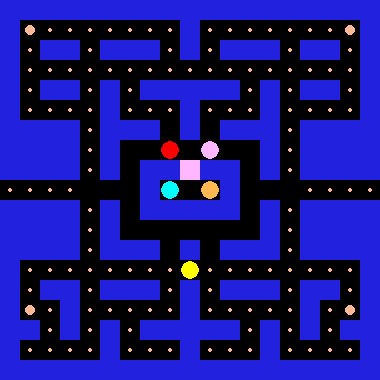

In [8]:
# Display the animated GIF directly in the notebook cell
print("Displaying Animated Replay:")
display(Image(filename=stats["gif_path"]))